In [1]:
# INSTALACIÓN DE DEPENDENCIAS
import subprocess
import sys

packages = [
    "pandas",
    "numpy",
    "matplotlib",
    "python-dotenv",
    "supabase"
]

for pkg in packages:
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        print(f"Instalando {pkg}...")
        subprocess.run(
            [sys.executable, "-m", "pip", "install", pkg, "-q"],
            check=True
        )

print("Todas las dependencias están disponibles.")

Instalando python-dotenv...
Todas las dependencias están disponibles.


In [2]:
# IMPORTAR LIBRERÍAS

import os
import warnings
from getpass import getpass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from supabase import create_client, Client
from IPython.display import display

warnings.filterwarnings("ignore")

# Estilo visual
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 14

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [3]:
# CONEXIÓN CON SUPABASE

ruta_actual = Path.cwd()

# Si el notebook se ejecuta dentro de la carpeta Notebook
if (ruta_actual.parent / ".env").exists():
    ROOT_DIR = ruta_actual.parent

# Si se ejecuta desde la raíz del proyecto
elif (ruta_actual / ".env").exists():
    ROOT_DIR = ruta_actual

else:
    raise FileNotFoundError(
        "No se encontró el archivo .env. "
        "Verifica que el notebook esté dentro de la carpeta Notebook."
    )

load_dotenv(ROOT_DIR / ".env")

SUPABASE_URL = "https://zytfjhwdrpbmkkrdbagj.supabase.co"
SUPABASE_KEY = os.getenv("SUPABASE_KEY")

if not SUPABASE_KEY:
    raise ValueError(
        "No se encontró SUPABASE_KEY dentro del archivo .env."
    )

supabase: Client = create_client(
    SUPABASE_URL,
    SUPABASE_KEY
)

print("Conexión con Supabase configurada correctamente.")

Conexión con Supabase configurada correctamente.


In [4]:
# INICIAR SESIÓN COMO ADMINISTRADORA

correo_admin = input("Correo de la cuenta administradora: ").strip()
password_admin = getpass("Contraseña: ")

response = supabase.auth.sign_in_with_password({
    "email": correo_admin,
    "password": password_admin
})

print(f"Sesión iniciada correctamente como: {response.user.email}")

Sesión iniciada correctamente como: admin123@gmail.com


In [5]:
# CARGAR TABLAS PRINCIPALES DEL PROYECTO

def consultar_tabla(nombre_tabla, columnas="*"):
    respuesta = (
        supabase
        .table(nombre_tabla)
        .select(columnas)
        .execute()
    )

    return pd.DataFrame(respuesta.data or [])


df_perfiles = consultar_tabla(
    "perfiles",
    "id, nombre_completo, rol"
)

df_participantes = consultar_tabla(
    "participantes",
    (
        "id_participante, id_usuario, nombre_completo, edad, "
        "genero, ciudad, nivel_educativo, fecha_registro"
    )
)

df_encuestas = consultar_tabla(
    "encuestas",
    "id_encuesta, id_participante, fecha_aplicacion, estado"
)

df_respuestas = consultar_tabla(
    "respuestas_encuesta",
    (
        "id_respuesta, id_encuesta, usa_misma_contrasena, "
        "usa_wifi_publico, reconoce_phishing, usa_doble_factor, "
        "tiene_antivirus, actualiza_contrasenas, "
        "comparte_info_redes, nivel_conocimiento"
    )
)

df_resultados = consultar_tabla(
    "resultados_riesgo",
    (
        "id_resultado, id_encuesta, puntaje_riesgo, "
        "clasificacion_riesgo, observacion, fecha_calculo"
    )
)

print("Tablas cargadas correctamente.")
print()
print(f"Perfiles: {len(df_perfiles)}")
print(f"Participantes: {len(df_participantes)}")
print(f"Encuestas: {len(df_encuestas)}")
print(f"Respuestas: {len(df_respuestas)}")
print(f"Resultados de riesgo: {len(df_resultados)}")

Tablas cargadas correctamente.

Perfiles: 3
Participantes: 3
Encuestas: 1
Respuestas: 1
Resultados de riesgo: 1


In [8]:
# EXCLUIR ADMINISTRADORES DEL ANÁLISIS

if not df_participantes.empty and not df_perfiles.empty:

    df_participantes = df_participantes.merge(
        df_perfiles[["id", "rol"]],
        left_on="id_usuario",
        right_on="id",
        how="left"
    )

    df_participantes = (
        df_participantes[
            df_participantes["rol"] == "usuario"
        ]
        .drop(
            columns=["id", "rol"],
            errors="ignore"
        )
        .copy()
    )

print("Participantes disponibles para el análisis:")
print(len(df_participantes))

display(df_participantes.head(10))

Participantes disponibles para el análisis:
2


,id_participante,id_usuario,nombre_completo,edad,genero,ciudad,nivel_educativo,fecha_registro
0,b1ab8762-17f0-491a-bb21-30521c4449e1,35428474-b319-4278-b562-383ce7b83105,Luis Flores,18,Masculino,La Ceiba,Universidad,2026-06-02T06:20:57.419889
1,02bcc551-8261-430d-aac2-a43792258c8e,10ad9150-60c2-47e1-9c20-2c5263458195,Heidy Sosa,20,Femenino,La Ceiba,Secundaria,2026-05-30T02:05:49.142187


In [9]:
# INTEGRACIÓN DE DATOS

df = (
    df_participantes
    .merge(
        df_encuestas,
        on="id_participante",
        how="left"
    )
    .merge(
        df_respuestas,
        on="id_encuesta",
        how="left"
    )
    .merge(
        df_resultados,
        on="id_encuesta",
        how="left"
    )
)

print("=== DATASET INTEGRADO DE CYBERLEY ===")
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")

display(df.head(10))

=== DATASET INTEGRADO DE CYBERLEY ===
Dimensiones: 2 filas x 25 columnas


,id_participante,id_usuario,nombre_completo,edad,genero,ciudad,nivel_educativo,fecha_registro,id_encuesta,fecha_aplicacion,...,usa_doble_factor,tiene_antivirus,actualiza_contrasenas,comparte_info_redes,nivel_conocimiento,id_resultado,puntaje_riesgo,clasificacion_riesgo,observacion,fecha_calculo
0,b1ab8762-17f0-491a-bb21-30521c4449e1,35428474-b319-4278-b562-383ce7b83105,Luis Flores,18,Masculino,La Ceiba,Universidad,2026-06-02T06:20:57.419889,654564d0-4f0c-47cd-830c-f196f1085bf6,2026-06-07T01:28:55.609422,...,False,False,False,False,medio,b14c84ed-5f32-438c-abf6-316d1be5d2cd,9.0,alto,Se identificaron varios hábitos inseguros. Es ...,2026-06-07T01:28:55.998395
1,02bcc551-8261-430d-aac2-a43792258c8e,10ad9150-60c2-47e1-9c20-2c5263458195,Heidy Sosa,20,Femenino,La Ceiba,Secundaria,2026-05-30T02:05:49.142187,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# INFORMACIÓN GENERAL DEL DATASET

print("=== INFORMACIÓN GENERAL ===")
df.info()

print()
print("=== TIPOS DE DATOS ===")
print(df.dtypes)

print()
print("=== VALORES NULOS ===")
print(df.isnull().sum())

print()
print("=== FILAS DUPLICADAS EXACTAS ===")
print(df.duplicated().sum())

=== INFORMACIÓN GENERAL ===
<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_participante        2 non-null      str    
 1   id_usuario             2 non-null      str    
 2   nombre_completo        2 non-null      str    
 3   edad                   2 non-null      int64  
 4   genero                 2 non-null      str    
 5   ciudad                 2 non-null      str    
 6   nivel_educativo        2 non-null      str    
 7   fecha_registro         2 non-null      str    
 8   id_encuesta            1 non-null      str    
 9   fecha_aplicacion       1 non-null      str    
 10  estado                 1 non-null      str    
 11  id_respuesta           1 non-null      str    
 12  usa_misma_contrasena   1 non-null      object 
 13  usa_wifi_publico       1 non-null      object 
 14  reconoce_phishing      1 non-null      str   

In [11]:
# LIMPIEZA DE DATOS

df_limpio = df.copy()

# Convertir fechas
columnas_fecha = [
    "fecha_registro",
    "fecha_aplicacion",
    "fecha_calculo"
]

for columna in columnas_fecha:
    if columna in df_limpio.columns:
        df_limpio[columna] = pd.to_datetime(
            df_limpio[columna],
            errors="coerce"
        )


# Convertir columnas numéricas
if "edad" in df_limpio.columns:
    df_limpio["edad"] = pd.to_numeric(
        df_limpio["edad"],
        errors="coerce"
    )

if "puntaje_riesgo" in df_limpio.columns:
    df_limpio["puntaje_riesgo"] = pd.to_numeric(
        df_limpio["puntaje_riesgo"],
        errors="coerce"
    )


# Normalizar textos
if "nombre_completo" in df_limpio.columns:
    df_limpio["nombre_completo"] = (
        df_limpio["nombre_completo"]
        .astype("string")
        .str.strip()
        .str.title()
    )

if "ciudad" in df_limpio.columns:
    df_limpio["ciudad"] = (
        df_limpio["ciudad"]
        .astype("string")
        .str.strip()
        .str.title()
    )

if "genero" in df_limpio.columns:
    df_limpio["genero"] = (
        df_limpio["genero"]
        .astype("string")
        .str.strip()
    )

if "nivel_educativo" in df_limpio.columns:
    df_limpio["nivel_educativo"] = (
        df_limpio["nivel_educativo"]
        .astype("string")
        .str.strip()
        .str.title()
    )

if "clasificacion_riesgo" in df_limpio.columns:
    df_limpio["clasificacion_riesgo"] = (
        df_limpio["clasificacion_riesgo"]
        .astype("string")
        .str.strip()
        .str.lower()
    )

print("Limpieza aplicada sobre una copia del dataset.")
display(df_limpio.head(10))

Limpieza aplicada sobre una copia del dataset.


,id_participante,id_usuario,nombre_completo,edad,genero,ciudad,nivel_educativo,fecha_registro,id_encuesta,fecha_aplicacion,...,usa_doble_factor,tiene_antivirus,actualiza_contrasenas,comparte_info_redes,nivel_conocimiento,id_resultado,puntaje_riesgo,clasificacion_riesgo,observacion,fecha_calculo
0,b1ab8762-17f0-491a-bb21-30521c4449e1,35428474-b319-4278-b562-383ce7b83105,Luis Flores,18,Masculino,La Ceiba,Universidad,2026-06-02 06:20:57.419889,654564d0-4f0c-47cd-830c-f196f1085bf6,2026-06-07 01:28:55.609422,...,False,False,False,False,medio,b14c84ed-5f32-438c-abf6-316d1be5d2cd,9.0,alto,Se identificaron varios hábitos inseguros. Es ...,2026-06-07 01:28:55.998395
1,02bcc551-8261-430d-aac2-a43792258c8e,10ad9150-60c2-47e1-9c20-2c5263458195,Heidy Sosa,20,Femenino,La Ceiba,Secundaria,2026-05-30 02:05:49.142187,NaN,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NaT


In [12]:
# DETECCIÓN DE PROBLEMAS DE CALIDAD

print("=== VALORES NULOS DESPUÉS DE LA LIMPIEZA ===")
display(
    df_limpio
    .isnull()
    .sum()
    .sort_values(ascending=False)
    .to_frame(name="cantidad_nulos")
)

print()
print("=== POSIBLES EDADES INVÁLIDAS ===")

if "edad" in df_limpio.columns:

    edades_invalidas = df_limpio[
        (df_limpio["edad"] < 10)
        | (df_limpio["edad"] > 100)
    ]

    display(edades_invalidas)

print()
print("=== POSIBLES DUPLICADOS DE PARTICIPANTES ===")

if all(
    columna in df_limpio.columns
    for columna in [
        "nombre_completo",
        "edad",
        "ciudad"
    ]
):

    duplicados = df_limpio[
        df_limpio.duplicated(
            subset=[
                "nombre_completo",
                "edad",
                "ciudad"
            ],
            keep=False
        )
    ]

    display(duplicados)

=== VALORES NULOS DESPUÉS DE LA LIMPIEZA ===


,cantidad_nulos
id_encuesta,1
tiene_antivirus,1
usa_doble_factor,1
reconoce_phishing,1
usa_wifi_publico,1
usa_misma_contrasena,1
id_respuesta,1
estado,1
fecha_aplicacion,1
actualiza_contrasenas,1



=== POSIBLES EDADES INVÁLIDAS ===


,id_participante,id_usuario,nombre_completo,edad,genero,ciudad,nivel_educativo,fecha_registro,id_encuesta,fecha_aplicacion,...,usa_doble_factor,tiene_antivirus,actualiza_contrasenas,comparte_info_redes,nivel_conocimiento,id_resultado,puntaje_riesgo,clasificacion_riesgo,observacion,fecha_calculo



=== POSIBLES DUPLICADOS DE PARTICIPANTES ===


,id_participante,id_usuario,nombre_completo,edad,genero,ciudad,nivel_educativo,fecha_registro,id_encuesta,fecha_aplicacion,...,usa_doble_factor,tiene_antivirus,actualiza_contrasenas,comparte_info_redes,nivel_conocimiento,id_resultado,puntaje_riesgo,clasificacion_riesgo,observacion,fecha_calculo


In [14]:
desc = df.describe().T

In [15]:
# ESTADÍSTICAS DESCRIPTIVAS

print("=== ESTADÍSTICAS DESCRIPTIVAS ===")

columnas_numericas = [
    columna
    for columna in [
        "edad",
        "puntaje_riesgo"
    ]
    if columna in df_limpio.columns
]

desc = df_limpio[
    columnas_numericas
].describe().T

desc["CV (%)"] = (
    desc["std"]
    / desc["mean"]
    * 100
).round(2)

desc["Rango"] = (
    desc["max"]
    - desc["min"]
)

display(desc.round(2))

=== ESTADÍSTICAS DESCRIPTIVAS ===


,count,mean,std,min,25%,50%,75%,max,CV (%),Rango
edad,2.0,19.0,1.41,18.0,18.5,19.0,19.5,20.0,7.44,2.0
puntaje_riesgo,1.0,9.0,NaN,9.0,9.0,9.0,9.0,9.0,NaN,0.0


In [16]:
# DISTRIBUCIÓN DE GÉNERO

print("=== DISTRIBUCIÓN DE GÉNERO ===")

participantes_unicos = (
    df_limpio[
        [
            "id_participante",
            "genero"
        ]
    ]
    .drop_duplicates()
)

gender_counts = (
    participantes_unicos["genero"]
    .value_counts()
)

print(gender_counts)

=== DISTRIBUCIÓN DE GÉNERO ===
genero
Masculino    1
Femenino     1
Name: count, dtype: int64[pyarrow]


In [17]:
# DISTRIBUCIÓN DE NIVELES DE RIESGO

print("=== DISTRIBUCIÓN DE NIVELES DE RIESGO ===")

risk_counts = (
    df_limpio["clasificacion_riesgo"]
    .dropna()
    .value_counts()
)

print(risk_counts)

print()
print("=== PORCENTAJES ===")

risk_percentages = (
    df_limpio["clasificacion_riesgo"]
    .dropna()
    .value_counts(
        normalize=True
    )
    .mul(100)
    .round(2)
)

print(risk_percentages)

=== DISTRIBUCIÓN DE NIVELES DE RIESGO ===
clasificacion_riesgo
alto    1
Name: count, dtype: int64[pyarrow]

=== PORCENTAJES ===
clasificacion_riesgo
alto    100.0
Name: proportion, dtype: double[pyarrow]


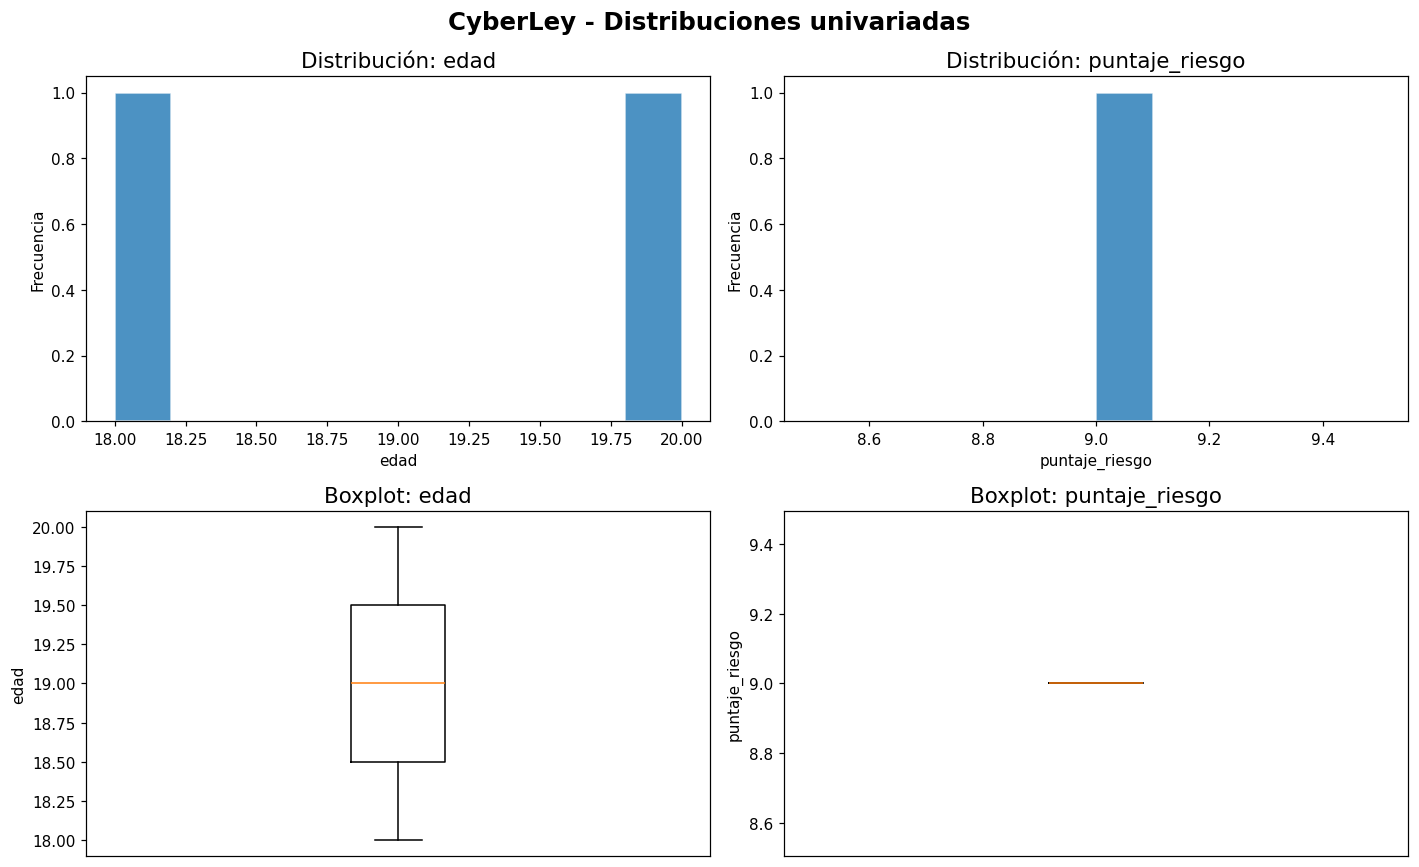

Figura 1 guardada.


In [18]:
# VISUALIZACIÓN 1: DISTRIBUCIONES UNIVARIADAS

columnas_disponibles = [
    columna
    for columna in [
        "edad",
        "puntaje_riesgo"
    ]
    if (
        columna in df_limpio.columns
        and not df_limpio[columna]
        .dropna()
        .empty
    )
]

fig, axes = plt.subplots(
    2,
    len(columnas_disponibles),
    figsize=(13, 8)
)

fig.suptitle(
    "CyberLey - Distribuciones univariadas",
    fontsize=16,
    fontweight="bold"
)

if len(columnas_disponibles) == 1:
    axes = np.array(axes).reshape(2, 1)

for i, columna in enumerate(columnas_disponibles):

    datos = df_limpio[columna].dropna()

    # Histograma
    axes[0, i].hist(
        datos,
        bins=10,
        edgecolor="white",
        alpha=0.8
    )

    axes[0, i].set_title(
        f"Distribución: {columna}"
    )

    axes[0, i].set_xlabel(columna)
    axes[0, i].set_ylabel("Frecuencia")

    # Boxplot
    axes[1, i].boxplot(
        datos,
        vert=True
    )

    axes[1, i].set_title(
        f"Boxplot: {columna}"
    )

    axes[1, i].set_ylabel(columna)
    axes[1, i].set_xticks([])

plt.tight_layout()

plt.savefig(
    ROOT_DIR / "Notebook" / "fig1_distribuciones.png",
    bbox_inches="tight"
)

plt.show()

print("Figura 1 guardada.")

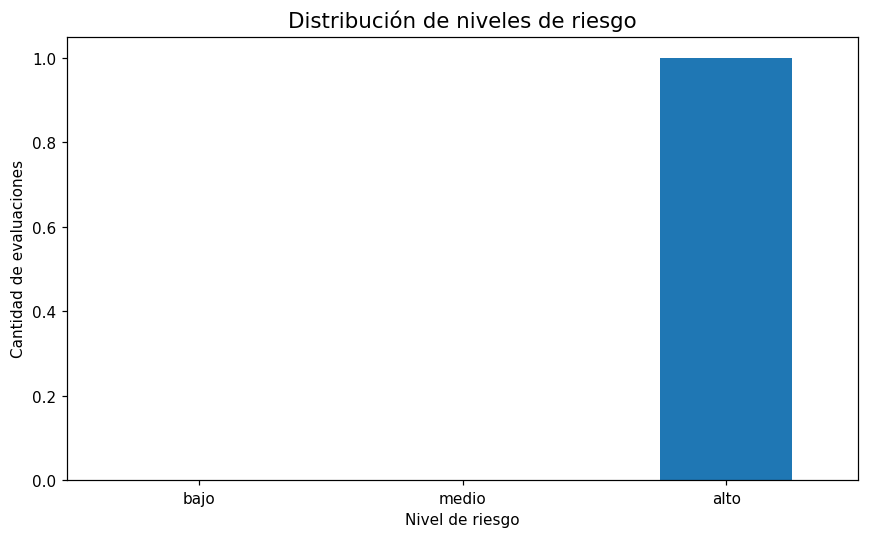

Figura 2 guardada.


In [19]:
# VISUALIZACIÓN 2: NIVELES DE RIESGO

conteo_riesgo = (
    df_limpio["clasificacion_riesgo"]
    .dropna()
    .value_counts()
    .reindex(
        [
            "bajo",
            "medio",
            "alto"
        ],
        fill_value=0
    )
)

plt.figure(
    figsize=(8, 5)
)

conteo_riesgo.plot(
    kind="bar"
)

plt.title(
    "Distribución de niveles de riesgo"
)

plt.xlabel(
    "Nivel de riesgo"
)

plt.ylabel(
    "Cantidad de evaluaciones"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    ROOT_DIR / "Notebook" / "fig2_niveles_riesgo.png",
    bbox_inches="tight"
)

plt.show()

print("Figura 2 guardada.")

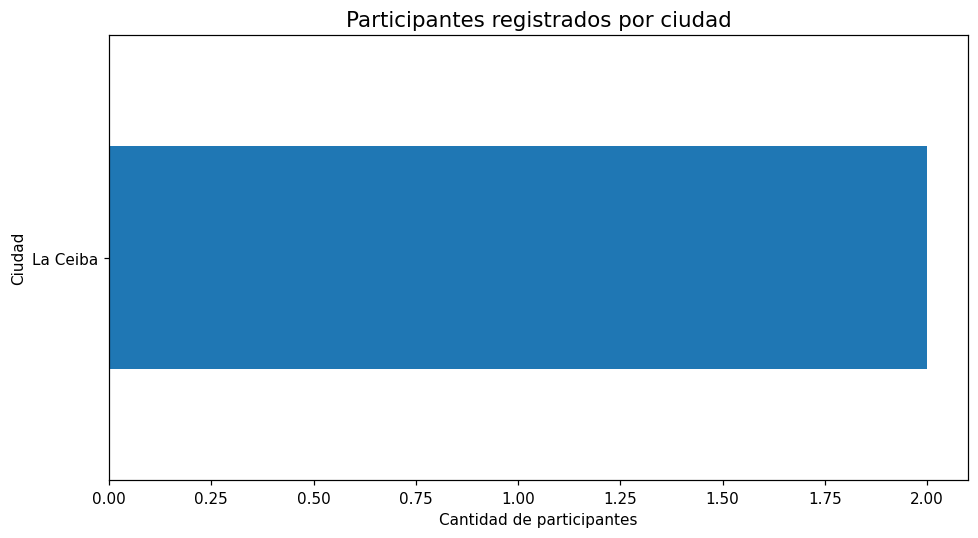

Figura 3 guardada.


In [20]:
# VISUALIZACIÓN 3: PARTICIPANTES POR CIUDAD

participantes_ciudad = (
    df_limpio[
        [
            "id_participante",
            "ciudad"
        ]
    ]
    .drop_duplicates()
    ["ciudad"]
    .dropna()
    .value_counts()
)

plt.figure(
    figsize=(9, 5)
)

participantes_ciudad.sort_values().plot(
    kind="barh"
)

plt.title(
    "Participantes registrados por ciudad"
)

plt.xlabel(
    "Cantidad de participantes"
)

plt.ylabel(
    "Ciudad"
)

plt.tight_layout()

plt.savefig(
    ROOT_DIR / "Notebook" / "fig3_participantes_ciudad.png",
    bbox_inches="tight"
)

plt.show()

print("Figura 3 guardada.")

,Hábito inseguro,Cantidad
0,Reutiliza contraseñas,1
2,No usa doble factor,1
3,No tiene antivirus,1
1,Usa Wi-Fi público,1
4,No actualiza contraseñas,1
5,Comparte información en redes,0


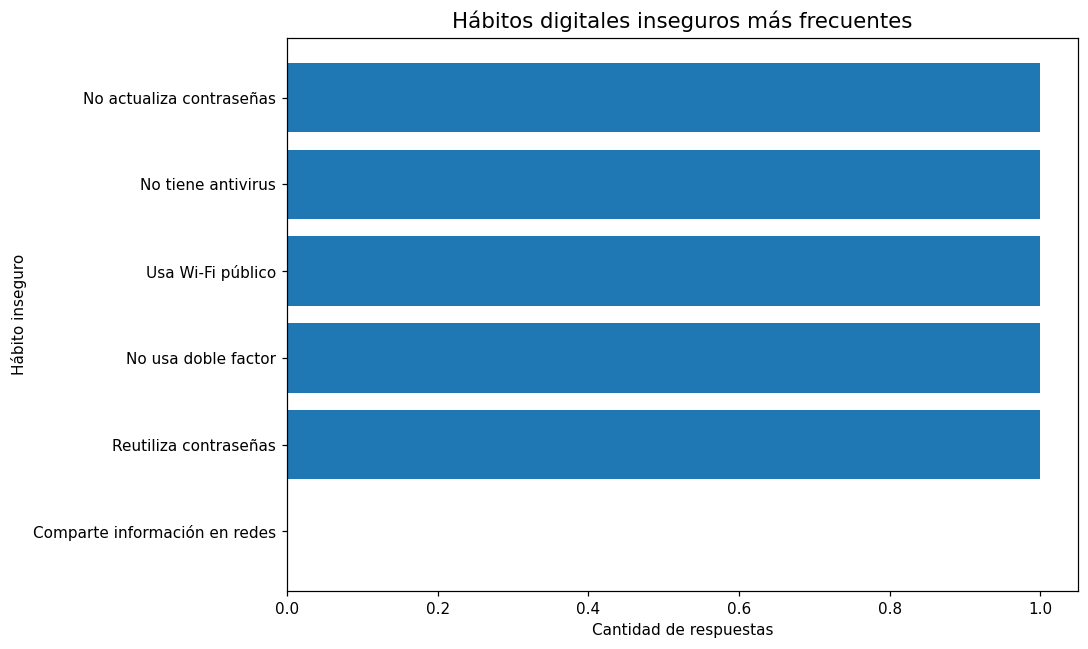

Figura 4 guardada.


In [22]:
# VISUALIZACIÓN 4: HÁBITOS INSEGUROS MÁS FRECUENTES

habitos = {
    "Reutiliza contraseñas": int(
        (
            df_limpio[
                "usa_misma_contrasena"
            ]
            == True
        ).sum()
    ),

    "Usa Wi-Fi público": int(
        (
            df_limpio[
                "usa_wifi_publico"
            ]
            == True
        ).sum()
    ),

    "No usa doble factor": int(
        (
            df_limpio[
                "usa_doble_factor"
            ]
            == False
        ).sum()
    ),

    "No tiene antivirus": int(
        (
            df_limpio[
                "tiene_antivirus"
            ]
            == False
        ).sum()
    ),

    "No actualiza contraseñas": int(
        (
            df_limpio[
                "actualiza_contrasenas"
            ]
            == False
        ).sum()
    ),

    "Comparte información en redes": int(
        (
            df_limpio[
                "comparte_info_redes"
            ]
            == True
        ).sum()
    )
}

df_habitos = (
    pd.DataFrame(
        list(
            habitos.items()
        ),
        columns=[
            "Hábito inseguro",
            "Cantidad"
        ]
    )
    .sort_values(
        "Cantidad",
        ascending=True
    )
)

display(
    df_habitos.sort_values(
        "Cantidad",
        ascending=False
    )
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    df_habitos["Hábito inseguro"],
    df_habitos["Cantidad"]
)

plt.title(
    "Hábitos digitales inseguros más frecuentes"
)

plt.xlabel(
    "Cantidad de respuestas"
)

plt.ylabel(
    "Hábito inseguro"
)

plt.tight_layout()

plt.savefig(
    ROOT_DIR / "Notebook" / "fig4_habitos_inseguros.png",
    bbox_inches="tight"
)

plt.show()

print("Figura 4 guardada.")

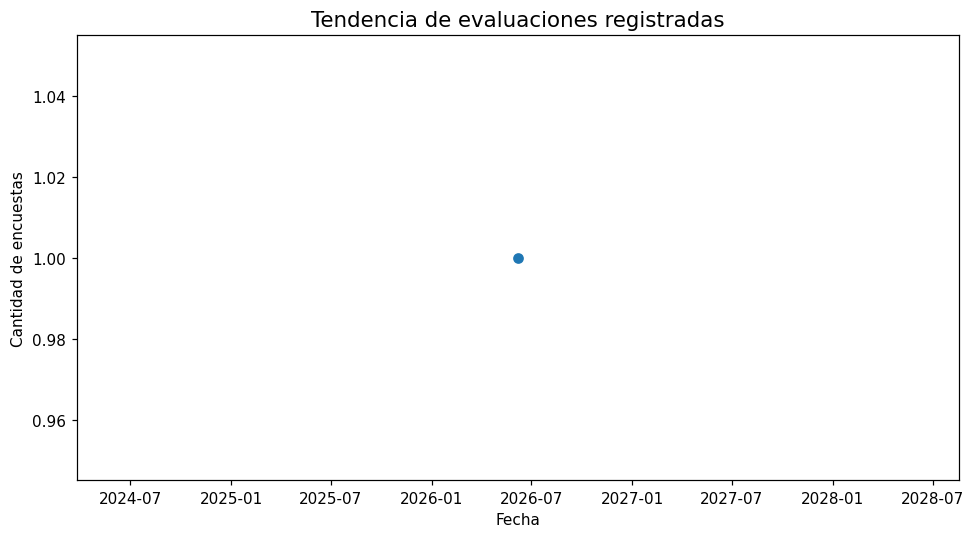

Figura 5 guardada.


In [23]:
# VISUALIZACIÓN 5: TENDENCIA DE ENCUESTAS REGISTRADAS

tendencia_encuestas = (
    df_limpio
    .dropna(
        subset=[
            "fecha_aplicacion"
        ]
    )
    .assign(
        fecha=lambda datos: (
            datos[
                "fecha_aplicacion"
            ]
            .dt.date
        )
    )
    .groupby(
        "fecha"
    )
    .size()
)

plt.figure(
    figsize=(9, 5)
)

tendencia_encuestas.plot(
    marker="o"
)

plt.title(
    "Tendencia de evaluaciones registradas"
)

plt.xlabel(
    "Fecha"
)

plt.ylabel(
    "Cantidad de encuestas"
)

plt.tight_layout()

plt.savefig(
    ROOT_DIR / "Notebook" / "fig5_tendencia_encuestas.png",
    bbox_inches="tight"
)

plt.show()

print("Figura 5 guardada.")

In [25]:
# EXPORTAR DATOS LIMPIOS

ruta_exportacion = (
    ROOT_DIR
    / "Notebook"
    / "cyberley_datos_limpios.csv"
)

df_limpio.to_csv(
    ruta_exportacion,
    index=False,
    encoding="utf-8-sig"
)

print(
    f"Archivo exportado correctamente en: "
    f"{ruta_exportacion}"
)

Archivo exportado correctamente en: c:\Users\ramos\OneDrive\Documentos\Ciencia de Datos\CyberLey\Notebook\cyberley_datos_limpios.csv
